<a href="dependencies/banner.jpeg">
      <img src="dependencies/banner.jpeg" alt="image0" width="100%">
</a>

# Qubit spectroscopy
Two-tone spectroscopy is used to determine the transition frequency between the |0⟩ and
|1⟩ states. In addition to the tone played on the readout line, a second
microwave tone is played on the drive line of the qubit. When the qubit drive frequency
becomes resonant with the qubit's |0⟩ $\rightarrow$ |1⟩ transition, the qubit absorbs energy and
changes its state. This change is then detected in the amplitude of the
readout signal at the previously calibrated resonator frequency.

In [1]:
from dependencies.analysis_utils import QubitSpectroscopyAnalysis
from xarray import open_dataset

from qblox_scheduler import HardwareAgent, Schedule
from qblox_scheduler.experiments import SetHardwareOption
from qblox_scheduler.operations import IdlePulse, Measure, Reset, SetClockFrequency, VoltageOffset
from qblox_scheduler.operations.expressions import DType
from qblox_scheduler.operations.loop_domains import arange, linspace

Generating hash table for SingleQubitClifford.
Hash table generated.
Generating hash table for TwoQubitCliffordCZ.


Hash table generated.
Generating hash table for TwoQubitCliffordZX.


Hash table generated.


/.venv/lib/python3.14/site-packages/quantify_core/visualization/instrument_monitor.py:13: QCoDeSDeprecationWarning: The `qcodes.utils.helpers` module is deprecated. Please consult the api documentation at https://microsoft.github.io/Qcodes/api/index.html for alternatives.
  from qcodes.utils.helpers import strip_attrs


## Setup
The hardware agent manages the connection to the instrument and ensures that pulses and acquisitions happen over the appropriate input and output channels of the Cluster.
The cell below creates an instance of the `HardwareAgent` based on the hardware- and device-under-test configuration files in the `./dependencies/configs` folder, allowing us to start doing measurements.
We also define some convenient aliases to use throughout our measurements.
For a more thorough discussion of the hardware- and device-under-test configuration files, check out [this tutorial](000_transmon_setup.ipynb).

In [2]:
# Set up hardware agent, this automatically connects to the instrument
hw_agent = HardwareAgent(
    hardware_configuration="./dependencies/configs/hw_config.json",
    quantum_device_configuration="./dependencies/configs/dut_config.json",
)

# convenience aliases
q0 = hw_agent.quantum_device.get_element("q0")  # Qubits 0 and 2 are measured using QRM-RF + QCM-RF
q2 = hw_agent.quantum_device.get_element("q2")
q3 = hw_agent.quantum_device.get_element("q3")  # Qubit 3 is measured using QRC

cluster = hw_agent.get_clusters()["cluster"]
hw_options = hw_agent.hardware_configuration.hardware_options
qubit = q0

/.venv/lib/python3.14/site-packages/qblox_scheduler/qblox/hardware_agent.py:556: UserWarning: cluster: Trying to instantiate cluster with ip 'None'.Creating a dummy cluster.
  warnings.warn(


## Experiment settings

In [3]:
# Drive attenuation settings. Should be an even number <= 30
drive_att = 30  # dB

# Drive frequency settings
f01_center = qubit.clock_freqs.f01  # Hz
f01_width = 50e6  # Hz
f01_npoints = 200

repetitions = 1e3

## Experiment schedule

In [4]:
two_tone_sched = Schedule("two_tone_spectroscopy")
# Set the drive attenuation for the experiment
two_tone_sched.add(SetHardwareOption("output_att", drive_att, f"{qubit.name}:mw-{qubit.name}.01"))

with two_tone_sched.loop(
    linspace(
        start=f01_center - f01_width / 2,
        stop=f01_center + f01_width / 2,
        num=f01_npoints,
        dtype=DType.FREQUENCY,
    )
) as freq:
    # Set a constant tone out of the drive line to probe the f01 frequency
    two_tone_sched.add(VoltageOffset(0.01, 0, port=qubit.ports.microwave, clock=qubit.name + ".01"))
    two_tone_sched.add(SetClockFrequency(clock=qubit.name + ".01", frequency=freq))

    two_tone_sched.add(Reset(qubit.name))
    with two_tone_sched.loop(arange(0, repetitions, 1, DType.NUMBER)):
        two_tone_sched.add(Measure(qubit.name, coords={"frequency": freq}, acq_channel="S_21"))

    # Reset drive line voltage to 0
    two_tone_sched.add(VoltageOffset(0, 0, port=qubit.ports.microwave, clock=qubit.name + ".01"))
    two_tone_sched.add(IdlePulse(4e-9))

# Execute the experiment
qs_data = hw_agent.run(two_tone_sched)
if cluster.is_dummy:
    example_data = open_dataset(
        "./dependencies/datasets/qubit_spectroscopy.hdf5", engine="h5netcdf"
    )
    qs_data = qs_data.update({"S_21": example_data.S_21})

/tmp/ipykernel_5593/2645899883.py:3: FutureWarning: Adding operation of type 'SetHardwareOption(name='set hardware option output_att to 30 for port q0:mw-q0.01')' without rel_time=None will not be supported in the future. It is not possible to satisfy this timing constraint.
  two_tone_sched.add(SetHardwareOption("output_att", drive_att, f"{qubit.name}:mw-{qubit.name}.01"))


## Analyze the experiment

findfont: Failed to find font weight 300, now using 400.


findfont: Failed to find font weight 300, now using 400.


findfont: Failed to find font weight 300, now using 400.


findfont: Failed to find font weight 300, now using 400.


findfont: Failed to find font weight 300, now using 400.


...

findfont: Failed to find font weight 300, now using 400.


findfont: Failed to find font weight 300, now using 400.


findfont: Failed to find font weight 300, now using 400.


findfont: Failed to find font weight 300, now using 400.


findfont: Failed to find font weight 300, now using 400.


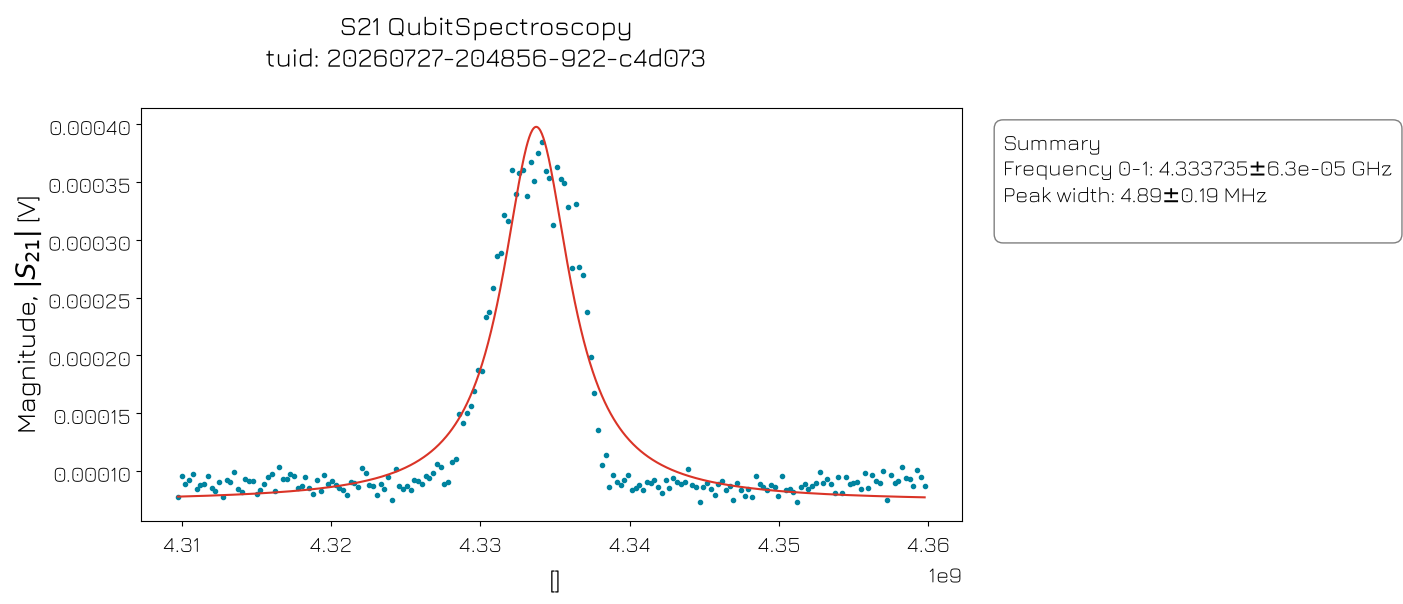

In [5]:
qs_analysis = QubitSpectroscopyAnalysis(qs_data).run()
qs_analysis.display_figs_mpl()

## Post-run

In [6]:
# Update device config
qubit.clock_freqs.f01 = qs_analysis.quantities_of_interest["frequency_01"].nominal_value

#### Update the device configuration file
After measurement, we may store the measured device properties inside a new file to use in future experiments.
The time-unique identifier ensures that it is easy to find back previously found measurement results.

In [7]:
hw_agent.quantum_device.to_json_file("./dependencies/configs", add_timestamp=True)

'./dependencies/configs/two_flux_tunable_transmons_2026-07-27_20-48-57_UTC.json'